<a href="https://colab.research.google.com/github/vn322/bag_of_bats/blob/main/%D1%82%D0%B5%D0%BE%D1%80%D0%B8%D1%8F_%D0%B2%D0%B5%D1%80%D0%BE%D1%8F%D1%82%D0%BD%D0%BE%D1%81%D1%82%D0%B8_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Теория вероятностей 2.

Сегодняшняя лекция будет весёлой, но от этого не менее важной. Мы разберём несколько классических задач и парадоксов теории вероятностей. Цель этой лекции - сформировать у вас интуитивное понимание неочевидных эффектов, возникающих при теоретической и практической работе с вероятностями.  

## Комбинаторика в теории вероятностей

**Комбинаторика** - это область математики, занимающаяся оценками количества сочетаний, перестановок, подвыборок и т.п. множеств, состоящих обычно из конечного числа объектов.

Для частотного подхода теории вероятностей очень важны выводы из комбинаторики. В этом разделе мы познакомимся с некоторыми классическими формулами и задачами из этой области знания.

### Задача о днях рождения

Для начала рассмотрим известную задачу о днях рождения. Она звучит следующим образом:

>В классе учится $N$ человек. Какова вероятность, что хотя бы у двух  из них день рождения в один день?

Интуитивно кажется, что эта вероятность довольно низкая, не так ли? Давайте это проверим!

Прежде чем перейти к вычислениям вероятности, закрепим $N=30$ и напишем численную симуляцию. В этой лекции мы будем часто писать код для симуляций процессов, чтобы убедиться, что мы всё посчитали верно.

In [ ]:
import random

def same_birthday():
    birthdays = [random.randint(0, 364) for _ in range(30)]
    if len(birthdays) != len(set(birthdays)):
        return True
    else:
        return False

In [ ]:
%%time

num_experiments = 100000
num_successes = 0

for _ in range(num_experiments):
    if same_birthday():
        num_successes += 1

probability = num_successes / num_experiments
print("Вероятность того, что хотя бы у 2 людей в классе из 30 человек день рождения в один день:", probability)

Вероятность того, что хотя бы у 2 людей в классе из 30 человек день рождения в один день: 0.70705
CPU times: user 3.06 s, sys: 4.65 ms, total: 3.06 s
Wall time: 3.07 s


Этот код работает следующим образом: мы случайно генерируем 30 дней рождения в виде числа от $0$ до $365$, каждое из которых задает определенный день в году. Мы  не будем обращать внимания на високосные года - они совсем немного отразятся на ответе. Дальше мы сравниваем длину списка дней рождения с длиной множества его уникальных элементов. Если они отличаются, то в какой-то день было минимум 2 дня рождения.

Результат впечатляет: вероятность превышает $70\%$. Узнаем, почему так.

#### Решение

Воспользуемся методом от обратного: посчитаем вероятность того, что день рождения каждого ученика в классе строго уникален, а затем вычтем эту вероятность из единицы.

Как мы помним, вероятность - это количество благоприятных исходов, деленное на количество всевозможных исходов. Благоприятным станет событие "день рождения каждого ученика уникален". Посчитаем для начала количество всевозможных исходов.

#### Всевозможные исходы
Пусть, для начала, в классе всего 1 ученик. Тогда количество всевозможных дней рождения такого скромного коллектива - $365$. Если теперь мы добавим к нему второго, то количество увеличится в $365$ раз, ведь день рождения первого ученика не влияет на то, когда родился второй!

То есть могут быть следующие пары дней рождения:
________________________
* 1 января, 1 января
* 1 января, 2 января
* 1 января, 3 января
* ...
* 1 января, 31 декабря
* 2 января, 1 января
* 2 января, 2 января
* ...
* 31 декабря, 31 декабря
_____________________________

Таких вариантов $365 \cdot 365 = 365^2$ штук.
Несложно догадаться, что, если мы добавим в класс еще одного ученика, количество вариантов увеличится в $365$ раз, потому что на каждую известную нам пару дней рождения первых двух учеников приходится ровно $365$ вариантов дня рождения третьего. И так далее. То есть общая формула всевозможных комбинаций дней рождения для всех учеников класса из $N$ человек: $365^N$ штук.

#### Позитивные исходы
Мы разобрались с числом всевозможных комбинаций. А какого же число позитивных исходов?

Пусть снова в классе есть всего 1 человек. Тогда число позитивных исходов все еще равно $365$, ведь в этом случае не важно, когда его день рождения. Добавим к нему второго ученика. Его день рождения может быть в любой день кроме дня рождения первого, то есть $365 - 1 = 364$  варианта. Добавим сюда третьего и получим еще $365 - 2 = 363$ варианта. То есть для $i$-го ученика число возможных позитивных вариантов равно $365 - i+1$ (если $i$ начинается с 1). По той же логике, что и в предыдущем разделе, перемножим возможные варианты для всех учеников и получим формулу:

$$P_+ = 365\cdot(365 - 1)\cdot(365 - 2)\cdot ... \cdot(365 - N + 1)$$
, где $P_+$ - количество позитивных вариантов.

Тогда формула вероятности следующая: $P(A) = 1 - \frac{P_+}{365^N} = 1 - \frac{365\cdot(365 - 1)\cdot(365 - 2)\cdot ... \cdot(365 - N + 1)}{365^N}$

Проверим, совпадает ли наш результат с полученным выше моделированием.

In [ ]:
%%time
def birthday_proba(N):
  p_pos = 1
  for i in range(1, N+1):
    p_pos*=(365-i+1)
  return 1 - p_pos/(365**N)

birthday_proba(30)

CPU times: user 42 µs, sys: 2 µs, total: 44 µs
Wall time: 47.2 µs


0.7063162427192686

Результат совпал!

## Задача о шарах в урне

Один из классических типов задач теории вероятностей - задачи о разноцветных шарах в урне. Рассмотрим одну из таких задач.

> В урне находится 10 белых и 5 черных шаров. Наудачу вытаскивают 3 шара. Найдите вероятность того, что среди них будет ровно 2 черных.



### Число сочетаний

Для решения этой задачи нам понадобится формула количества способов выбрать сочетание, состоящее из $k$ объектов из группы, состоящей из $n$ объектов. Например, нам нужно составить группу из $k$ дежурных по столовой из класса, в котором учится $n$ учеников. Число сочетаний "из $n$ по $k$" - это ответ на вопрос "сколько таких различных групп в принципе может быть составлено". Такой комбинаторный объект обозначается $C_n^k$. Например, $C_3^2$ - это число способов выбрать 2 объекта из 3. Несложно убедиться, например, что $C_3^2 = 3$, поскольку существует всего 3 способа выбрать 2 из трёх объектов (из группы $(A, B, C)$ можно составить 3 подгруппы: $(A,B), (B, C)$ и $(A, C)$). Оказывается, существует формула для вычисления $C_n^k$ для произвольных $n$ и $k$:
$$C_n^k = \frac{n!}{k!(n - k)!}$$

Согласно этой формуле, $C_3^2 = \frac{3!}{2!1!} = 3$, в этом случае формула работает отлично. $C_n^k$ также иногда называют *биномиальными коэффициентами*. Это связано с тем, что те же самые коэффициенты встречаются в формуле бинома Ньютона:
$$(a + b)^n = C_n^0a^nb^0 + C_n^1a^{(n-1)}b^1 + ... + C_n^ia^{(n-i)}b^i + ... C_n^na^0b^n$$

Мы не будем вдаваться в подробности теории биномиальных коэффициентов, вместо этого мы воспользуемся формулой для решения рассматриваемой задачи. Но, прежде чем перейти к решению, мы проведём численное моделирование.

In [ ]:
import random

def black_balls(iterations):
    count_favorable = 0
    for _ in range(iterations):
        urn = ['W']*10 + ['B']*5
        sample = random.sample(urn, 3)
        if sample.count('B') == 2:
            count_favorable += 1
    probability = count_favorable / iterations
    return probability

iterations = 100000
result = black_balls(iterations)
print("Вероятность того, что среди 3 вытянутых шаров будет ровно 2 черных:", result)

Вероятность того, что среди 3 вытянутых шаров будет ровно 2 черных: 0.22003


Проверим, совпадает ли эта оценка с теоретическим решением.

### Решение

Как и в прошлой задаче, определим сначала количество всевозможных вариантов реализации нашего эксперимента. Эти варианты вычисляются через число сочетаний. Мы не обращаем внимание на цвет шара, нас интересует лишь количество всевозможных вариантов составления группы из $3$ случайных шаров, если выбираем мы их из $10 + 5 = 15$ шаров в урне. Это число равно $C_{15}^3$.

$$C_{15}^3 = \frac{15!}{3!12!} = 455$$

Какое число позитивных результатов? Позитивный результат характеризуется тем, что мы вытащили $2$ черных и $1$ белый шар. Соответственно число способов сделать это равно числу способов вытянуть $2$ черных шара из $5$, умноженное на число способов вытянуть $1$ белых из $10$:

$$C_5^2 = \frac{5!}{2!3!} = 10$$
$$C_{10}^1 = \frac{10!}{1!9!} = 10$$




Итого, теоретическая оценка:

In [ ]:
10*10/455

0.21978021978021978

Вероятность снова очень близка к вероятности, полученной при численном моделировании. Это позволяет нам убедиться в правильности выполненных вычислений.

## Парадокс Монти Холла

Парадокс Монти Холла возник в результате одной из игр в телевизионном шоу **"Let's Make a Deal"**, ведущим которого был Монти Холл. В ходе игры участнику предлагалось выбрать одну из трех дверей, за одной из которых находился приз (автомобиль), а за двумя другими - козы. После того, как участник сделал свой выбор, ведущий открывал одну из оставшихся дверей, за которой находилась коза, и предлагал участнику изменить свой выбор.

То есть алгоритм действий игрока следующий:

1) Выбрать одну из трёх дверей

2) Ведущий открывает одну из двух оставшихся, за которой находится коза

3) Вы можете поменять свой выбор, то есть выбрать другую закрытую дверь

**Вопрос:** выгодно ли менять свой выбор?

Подумайте минуту прежде чем читать дальше.

Давайте для начала проведём симуляцию - многократно заставим участников случайным образом менять или не менять выбор и посчитаем процент успеха в каждом из этих случаев.

In [ ]:
import random

def monty_hall_simulation(num_simulations):
    stay_wins = 0
    switch_wins = 0

    for _ in range(num_simulations):
        doors = [0, 0, 1]  # 0 - коза, 1 - автомобиль
        random.shuffle(doors)

        player_choice = random.randint(0, 2)

        # Монти открывает одну из дверей с козой
        monty_choice = random.choice([i for i in range(3) if i != player_choice and doors[i] == 0])

        # Игрок решает остаться при своем выборе или поменять дверь
        stay_choice = doors[player_choice]
        switch_choice = doors[[i for i in range(3) if i != player_choice and i != monty_choice][0]]

        if stay_choice == 1:
            stay_wins += 1
        if switch_choice == 1:
            switch_wins += 1

    stay_win_percentage = stay_wins / num_simulations * 100
    switch_win_percentage = switch_wins / num_simulations * 100

    print(f"Игрок, не меняющий выбор, выигрывает в {stay_win_percentage:.2f}% случаях.")
    print(f"При смене выбора игрок выигрывает в {switch_win_percentage:.2f}% случаях.")


In [ ]:
monty_hall_simulation(100)

Игрок, не меняющий выбор, выигрывает в 33.11% случаях.
При смене выбора игрок выигрывает в 66.89% случаях.


Получается, что люди, меняющие изначальный выбор выигрывают в два раза чаще тех, кто этот выбор не меняет. Но почему?.. Возможно, проблема в том, что 1000 - слишком маленькое число?

In [ ]:
monty_hall_simulation(10000)

Игрок, не меняющий выбор, выигрывает в 34.04% случаях.
При смене выбора игрок выигрывает в 65.96% случаях.


Проблема явно не в этом... Кажется, это действительно существующий эффект. Давайте разберёмся, из-за чего он возникает.

### Решение парадокса

Для начала давайте поймём, в чем вообще проявляется случайность в этой игре. Ведь человек, зная её правила, не выбирает итоговую дверь совершенно случайным образом. Он придерживается определённой **стратегии**, а именно - поменять свой выбор или нет. Для того, чтобы убедиться в этом, давайте проведём симуляцию для человека, который не знает заранее, что он выберет - менять изначальный выбор или нет. Этот выбор он делает случайно.

In [ ]:
import random

def monty_hall_simulation_zero(num_simulations):
    wins = 0

    for _ in range(num_simulations):
        doors = [0, 0, 1]  # 0 - коза, 1 - автомобиль
        random.shuffle(doors)

        player_choice = random.randint(0, 2)

        # Монти открывает одну из дверей с козой
        monty_choice = random.choice([i for i in range(3) if i != player_choice and doors[i] == 0])

        # Игрок решает остаться при своем выборе или поменять дверь
        stay_choice = doors[player_choice]
        switch_choice = doors[[i for i in range(3) if i != player_choice and i != monty_choice][0]]

        final_choice = random.choice([stay_choice, switch_choice])
        if final_choice:
          wins += 1

    win_percentage = wins / num_simulations * 100

    print(f"Игрок, не придерживающийся стратегии, выигрывает в {win_percentage:.2f}% случаях.")


In [ ]:
monty_hall_simulation_zero(10000)

Игрок, не придерживающийся стратегии, выигрывает в 50.82% случаях.


То есть отсутствие стратегии приводит к совершенно случайному гаданию.

Таким образом, существует две стратегии: одна успешная - менять выбор, и одна неудачная - оставаться при своём исходном выборе. Для обеих стратегий выигрыш зависит лишь от того, на какую дверь изначально показал человек, поскольку все дальнейшие действия однозначно определены.

**Для стратегии с неизменным выбором:**

Пусть изначально человек показал на дверь, за которой был приз. Тогда не менять свой выбор - правильная стратегия, после открытия одной из двух "пустых" дверей, выбор останется на двери, за которой приз.

Если же человек изначально показал на дверь, за которой была коза, то стратегия проигрышная, он абсолютно точно выбирает козу.

То есть, мы получаем приз с вероятностью, которая равна вероятности того, что мы изначально показали на правильную дверь. А ведь эта вероятность всего $\frac{1}{3}$, то есть примерно $33\%$, как и показала наша симуляция.

**Для стратегии с изменением выбора:**

Здесь же всё ровно наоборот: человек, изначально выбравший правильную дверь, в итоге проигрывает, поскольку гарантированно меняет свой выбор. Человек же, выбравший изначально неправильную дверь, получает преимущество, поскольку вторую неправильную дверь он не выберет. Из двух осташихся дверей он гарантированной выбирает верную. То есть задача игры сводится к тому, чтобы изначально выбрать **неправильную дверь**, а это можно сделать с вероятностью $\frac{2}{3}$, то есть примерно $66\%$

**Стратегия со случайным выбором:**

Самое интересно происходит со стратегией со случайным выбором. Пусть у нас есть 3 события: $A$ - изначально выбрать правильную дверь, $B$ - поменять свой выбор и $C$ - выиграть игру.

Мы знаем, что $P(B) = \frac{1}{2}$, а $P(A) = \frac{1}{3}$

Достижение успеха возможно в двух случаях: одновременное выполнение $A$ и невыполнение $B$, а также невыполнение $A$ и выполнение $B$. Невыполнение некоторого события будем отмечать так: $P($~$A) = 1 - P(A)$.

То есть

$P(C) = P(A)\cdot P($ ~ $B) + P(B)⋅P($ ~ $A) = \frac{1}{3}⋅\frac{1}{2} + \frac{1}{2} ⋅ \frac{2}{3} = 0.5$

Это то самое случайное угадывание, которое мы и определили в симуляции.

### Метод Монте-Карло

Метод численного моделирования некоторого процесса, основанного на вероятностных решениях, называется **методом Монте-Карло**.

Суть метода заключается в том, что случайные числа используются для аппроксимации решения задачи, которая может быть сложной или невозможной для решения аналитическими методами. Для этого генерируются случайные числа, которые затем используются для моделирования поведения системы или процесса.

Преимущества метода Монте-Карло включают его универсальность и применимость к широкому спектру задач, а также возможность получения приближенного решения даже для сложных задач. Однако, недостатком метода является его вычислительная сложность и необходимость генерации большого количества случайных чисел для достижения точного результата.

Метод Монте-Карло широко используется в различных областях, таких как физика, финансы, биология, компьютерная графика и другие. Он позволяет проводить численное моделирование и анализ систем, которые не могут быть описаны аналитически, и является мощным инструментом для исследования сложных процессов и явлений.

#### Пример

Помимо приведённых выше примеров, приведём еще один - вычисление числа Пи при помощи метода Монте-Карло. Идея состоит в следующем:

Из геометрии мы знаем, что площадь квадрата $S_1 = a^2$, а круга с радиусом $\frac{a}{2}$: $S_2 = \pi\frac{a^2}{4}$

Тогда число $\pi$ можно посчитать, поделив одну площадь на другую:

$\frac{S_2}{S_1} = \frac{a^2\frac{\pi}{4}}{a^2} = \frac{\pi}{4} → \pi = 4\frac{S_2}{S_1}$

Отношение площадей $\frac{S_2}{S_1}$ мы посчитаем, сгенерировав большое количество случайных точек в некотором квадрате со стороной 1 (хотя здесь не так важна сторона квадрата, она сократилась), и поделим количество всех точек на количество точек, попавших в вписанный круг с диаметром 1.

In [ ]:
import random
import matplotlib.pyplot as plt

# Функция для проверки, попадает ли точка в круг
def is_inside_circle(x, y):
    return x**2 + y**2 <= 1

def MonteKarloPi(num_points):
  # Счетчик точек, попавших в круг
  num_inside_circle = 0

  # Списки для хранения координат точек
  x_inside = []
  y_inside = []
  x_outside = []
  y_outside = []

  # Генерация точек и проверка, попали ли они в круг
  for _ in range(num_points):
      x = random.uniform(-1, 1)
      y = random.uniform(-1, 1)

      if is_inside_circle(x, y):
          num_inside_circle += 1
          x_inside.append(x)
          y_inside.append(y)
      else:
          x_outside.append(x)
          y_outside.append(y)

  # Вычисление числа Пи
  pi_estimate = 4 * num_inside_circle / num_points

  # Вывод результата
  print("Оценка числа Пи методом Монте-Карло:", pi_estimate)

  # Рисуем квадрат
  plt.figure(figsize=(6,6))
  plt.gca().add_artist(plt.Rectangle((-1, -1), 2, 2, fill=False))

  # Рисуем круг
  circle = plt.Circle((0, 0), 1, color='r', fill=False)
  plt.gca().add_artist(circle)

  # Рисуем точки
  plt.scatter(x_inside, y_inside, color='b', label='Внутри круга')
  plt.scatter(x_outside, y_outside, color='g', label='Снаружи круга')

  plt.axis('equal')
  plt.legend()
  plt.show()

Оценка числа Пи методом Монте-Карло: 3.172


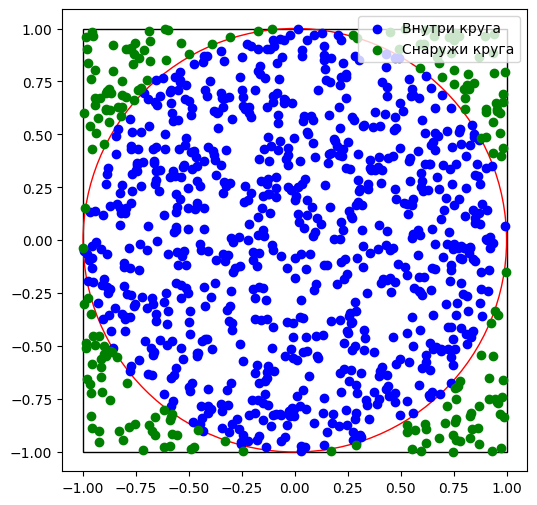

In [ ]:
MonteKarloPi(1000)

Увеличивая количество точек, добьемся хорошей точности:

Оценка числа Пи методом Монте-Карло: 3.1168


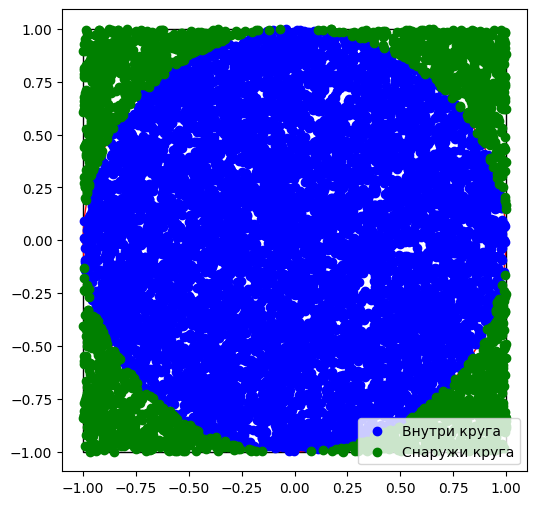

In [ ]:
MonteKarloPi(10_000)

Получается довольно хорошее приближение числа Пи!

Конечно, существуют способы посчитать число Пи намного проще и точнее. Но для некоторых сложных задач таких способов нет. Метод Монте-Карло активно применяется для решения таких задач.